#**Load Dataset**

In [ ]:
# Import Required Libraries
import pandas as pd
import numpy as np

# Load Dataset
df=pd.read_csv('/content/Housing.csv')
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7229300521,20141013T000000,231300.0,2,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


#**Summary Statistics and Initial Overview**

In [ ]:
# Summary statistics (mean, median, std) for numeric columns

numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

summary = df[numeric_cols].describe().T  # contains mean, std, min, 25%, 50%, 75%, max
summary['median'] = df[numeric_cols].median()
summary = summary[['mean', 'median', 'std', 'min', '25%', '50%', '75%', 'max', 'count']]
summary.style.format("{:.3f}")

,mean,median,std,min,25%,50%,75%,max,count
id,4580306147.710,3904930410.000,2876569751.889,1000102.000,2123049194.000,3904930410.000,7308900445.000,9900000190.000,21613.000
price,540088.577,450000.000,367126.825,75000.000,321950.000,450000.000,645000.000,7700000.000,21613.000
bedrooms,3.371,3.000,0.930,0.000,3.000,3.000,4.000,33.000,21613.000
bathrooms,2.115,2.250,0.770,0.000,1.750,2.250,2.500,8.000,21613.000
sqft_living,2079.900,1910.000,918.441,290.000,1427.000,1910.000,2550.000,13540.000,21613.000
sqft_lot,15106.968,7618.000,41420.512,520.000,5040.000,7618.000,10688.000,1651359.000,21613.000
floors,1.494,1.500,0.540,1.000,1.000,1.500,2.000,3.500,21613.000
waterfront,0.008,0.000,0.087,0.000,0.000,0.000,0.000,1.000,21613.000
view,0.234,0.000,0.766,0.000,0.000,0.000,0.000,4.000,21613.000
condition,3.409,3.000,0.651,1.000,3.000,3.000,4.000,5.000,21613.000


In [ ]:
# Correlation of Features

numeric_col=df.select_dtypes(include=('number'))

numeric_col.corr()

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
id,1.000000,-0.016762,0.001240,0.005158,-0.012259,-0.132109,0.018524,-0.002721,0.011592,-0.023784,0.008130,-0.010843,-0.005152,0.021379,-0.016907,-0.008221,-0.001891,0.020798,-0.002903,-0.138798
price,-0.016762,1.000000,0.308377,0.525136,0.702035,0.089661,0.256793,0.266370,0.397294,0.036361,0.667434,0.605567,0.323816,0.054011,0.126434,-0.053201,0.307003,0.021626,0.585378,0.082447
bedrooms,0.001240,0.308377,1.000000,0.515932,0.576693,0.031713,0.175466,-0.006578,0.079543,0.028502,0.356978,0.477614,0.303112,0.154198,0.018850,-0.152754,-0.008913,0.129482,0.391666,0.029256
bathrooms,0.005158,0.525136,0.515932,1.000000,0.754665,0.087740,0.500653,0.063744,0.187737,-0.124982,0.664983,0.685342,0.283770,0.506019,0.050739,-0.203866,0.024573,0.223042,0.568634,0.087175
sqft_living,-0.012259,0.702035,0.576693,0.754665,1.000000,0.172826,0.353949,0.103818,0.284611,-0.058753,0.762704,0.876597,0.435043,0.318049,0.055363,-0.199430,0.052529,0.240223,0.756420,0.183286
sqft_lot,-0.132109,0.089661,0.031713,0.087740,0.172826,1.000000,-0.005201,0.021604,0.074710,-0.008958,0.113621,0.183512,0.015286,0.053080,0.007644,-0.129574,-0.085683,0.229521,0.144608,0.718557
floors,0.018524,0.256793,0.175466,0.500653,0.353949,-0.005201,1.000000,0.023698,0.029444,-0.263768,0.458183,0.523885,-0.245705,0.489319,0.006338,-0.059121,0.049614,0.125419,0.279885,-0.011269
waterfront,-0.002721,0.266370,-0.006578,0.063744,0.103818,0.021604,0.023698,1.000000,0.401857,0.016653,0.082775,0.072075,0.080588,-0.026161,0.092885,0.030285,-0.014274,-0.041910,0.086463,0.030703
view,0.011592,0.397294,0.079543,0.187737,0.284611,0.074710,0.029444,0.401857,1.000000,0.045990,0.251321,0.167649,0.276947,-0.053440,0.103917,0.084827,0.006157,-0.078400,0.280439,0.072575
condition,-0.023784,0.036361,0.028502,-0.124982,-0.058753,-0.008958,-0.263768,0.016653,0.045990,1.000000,-0.144674,-0.158214,0.174105,-0.361417,-0.060618,0.003026,-0.014941,-0.106500,-0.092824,-0.003406


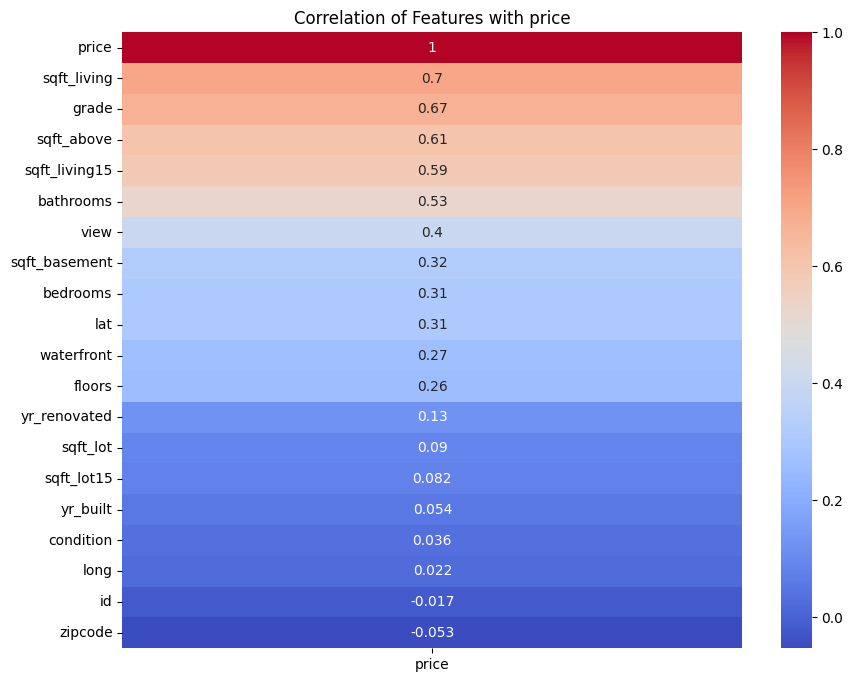

In [ ]:
# Correlation of Features With Target

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr[['price']].sort_values(by='price', ascending=False), annot=True, cmap='coolwarm')
plt.title('Correlation of Features with price')
plt.show()

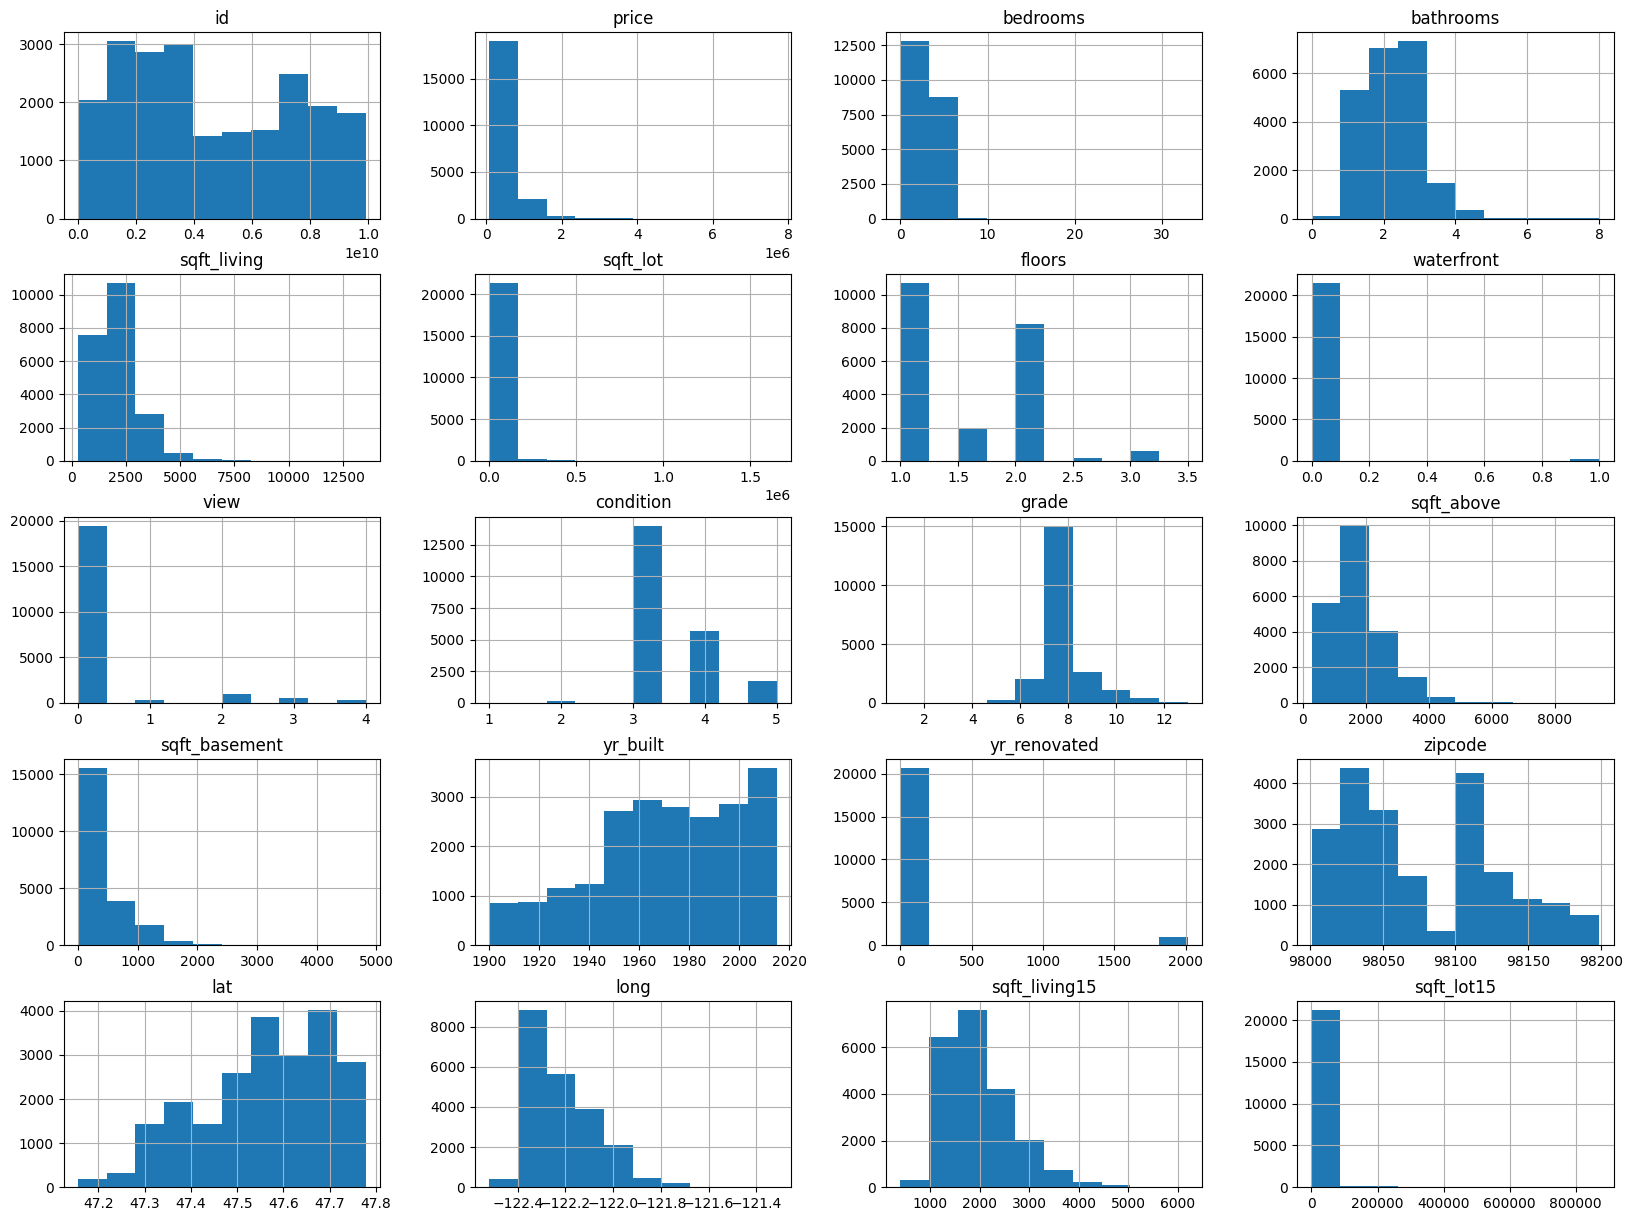

In [ ]:
# Initial Visualisation of Raw Data

numeric_col.hist(figsize=(20,15))

plt.show()

In [ ]:
# Checking Skewness of Numerical Features
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

skewness = df[numeric_cols].skew().sort_values(ascending=False)
print("\n--- Skewness of Numerical Features ---")
print(skewness)


--- Skewness of Numerical Features ---
sqft_lot         13.060019
waterfront       11.385108
sqft_lot15        9.506743
yr_renovated      4.549493
price             4.024080
view              3.395750
bedrooms          1.974028
sqft_basement     1.577965
sqft_living       1.471555
sqft_above        1.446664
sqft_living15     1.108181
condition         1.032805
long              0.885053
grade             0.771103
floors            0.616177
bathrooms         0.511108
zipcode           0.405661
id                0.243327
yr_built         -0.469805
lat              -0.485270
dtype: float64


#**Data Wrangling**

In [ ]:
# Basic info of Data

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

In [ ]:
# Checking Missing Values

df.isnull().sum()

,0
id,0
date,0
price,0
bedrooms,0
bathrooms,0
sqft_living,0
sqft_lot,0
floors,0
waterfront,0
view,0


In [ ]:
# Checking for Duplicates

df.duplicated().sum()

np.int64(0)

In [ ]:
# Identify outliers using IQR

numeric_cols=df.select_dtypes(include=['number']).columns.tolist()

print("\nIdentifying outliers using IQR:")
outlier_indices = {}
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index
    outlier_indices[col] = outliers
    print(f"  {col:>20}: {len(outliers)} outliers identified")

# Combine indices from all columns
all_outlier_indices = [idx for indices in outlier_indices.values() for idx in indices]
all_outlier_indices = list(set(all_outlier_indices)) # Remove duplicates

print(f"\nTotal unique outliers identified across numeric columns: {len(all_outlier_indices)}")


Identifying outliers using IQR:
                    id: 0 outliers identified
                 price: 1146 outliers identified
              bedrooms: 546 outliers identified
             bathrooms: 571 outliers identified
           sqft_living: 572 outliers identified
              sqft_lot: 2425 outliers identified
                floors: 0 outliers identified
            waterfront: 163 outliers identified
                  view: 2124 outliers identified
             condition: 30 outliers identified
                 grade: 1911 outliers identified
            sqft_above: 611 outliers identified
         sqft_basement: 496 outliers identified
              yr_built: 0 outliers identified
          yr_renovated: 914 outliers identified
               zipcode: 0 outliers identified
                   lat: 2 outliers identified
                  long: 256 outliers identified
         sqft_living15: 544 outliers identified
            sqft_lot15: 2194 outliers identified

Total unique

In [ ]:
# Cleaning the Outliers (Masking Renovation Year and Waterfront)

protect_mask = (df['yr_renovated'] > 0) | (df['waterfront'] > 0)

# Drop only rows that are outliers AND NOT protected
to_drop_mask = df.index.isin(all_outlier_indices) & (~protect_mask)
df_clean = df.loc[~to_drop_mask].reset_index(drop=True)


In [ ]:
df_clean.shape

(15969, 21)

##**Feature Engineering**

* **Sale Date:** Helps calculating the House Age
* **House_Age:** Newer homes often cost more — captures depreciation effect.
* **Living_to_Lot_Ratio:** Indicates density — premium locations often have higher ratio.
* **Basement presence:** Basements add extra livable space.
* **Baths_per_Bedroom:** Comfort ratio; higher = premium design.
* **Renovated:** Renovations increase property value. (0 in dataset if never renovated)
* **Years_Since_Renovation:** Recent renovations boost price more than old ones. (0 in dataset if never renovated)



In [ ]:
def feature_engineering(df_clean):
    df_fe = df_clean.copy()

    if 'date' in df_fe.columns:
        df_fe['sale_date'] = pd.to_datetime(df_fe['date'], errors='coerce')
        sale_year = df_fe['sale_date'].dt.year.fillna(2025)
    else:
        sale_year = pd.Series(2025, index=df_fe.index)

    df_fe['House_Age'] = sale_year - df_fe['yr_built']
    df_fe['Living_to_Lot_Ratio'] = df_fe['sqft_living'] / df_fe['sqft_lot'].replace(0, np.nan)
    df_fe['Basement_Present'] = (df_fe['sqft_basement'] > 0).astype(int)
    df_fe['Baths_per_Bedroom'] = np.where(df_fe['bedrooms'] > 0, df_fe['bathrooms'] / df_fe['bedrooms'], 0.0)
    df_fe['Renovated'] = (df_fe['yr_renovated'] > 0).astype(int)
    df_fe['Years_Since_Renovation'] = np.where(df_fe['yr_renovated'] > 0, sale_year - df_fe['yr_renovated'], 0)

# Basic hygiene
    df_fe.replace([np.inf, -np.inf], np.nan, inplace=True)

    return df_fe


# Apply feature engineering
df_fe = feature_engineering(df_clean)


In [ ]:
df_fe.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,long,sqft_living15,sqft_lot15,sale_date,House_Age,Living_to_Lot_Ratio,Basement_Present,Baths_per_Bedroom,Renovated,Years_Since_Renovation
0,7229300521,20141013T000000,231300.0,2,1.00,1180,5650,1.0,0,0,...,-122.257,1340,5650,2014-10-13,59,0.208850,0,0.500000,0,0
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,-122.319,1690,7639,2014-12-09,63,0.354874,1,0.750000,1,23
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,-122.233,2720,8062,2015-02-25,82,0.077000,0,0.500000,0,0
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,-122.393,1360,5000,2014-12-09,49,0.392000,1,0.750000,0,0
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,-122.045,1800,7503,2015-02-18,28,0.207921,0,0.666667,0,0


In [ ]:
# Saving the Clean Dataset for EDA and Regression
df_fe.to_csv('Cleaned_Housing.csv', index=False)

# **Exploratory Data Analysis**

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numeric columns for correlation
numeric_corr = df_fe.select_dtypes(include=['int64', 'float64'])

# Compute correlation with price
price_corr = numeric_corr.corr()['price'].sort_values(ascending=False)

# Display correlations
print("Correlation of features with price:")
print(price_corr)


Correlation of features with price:
price                     1.000000
sqft_living               0.607239
grade                     0.558069
view                      0.502386
sqft_living15             0.478034
sqft_above                0.470006
waterfront                0.437224
bathrooms                 0.396043
lat                       0.346003
sqft_basement             0.309605
yr_renovated              0.261399
Renovated                 0.260872
bedrooms                  0.231181
Baths_per_Bedroom         0.220111
floors                    0.195794
Basement_Present          0.178746
Years_Since_Renovation    0.153208
Living_to_Lot_Ratio       0.149684
sqft_lot15                0.091481
sqft_lot                  0.088686
House_Age                 0.058471
condition                 0.043094
id                        0.015075
long                      0.006109
zipcode                  -0.001685
yr_built                 -0.058537
Name: price, dtype: float64


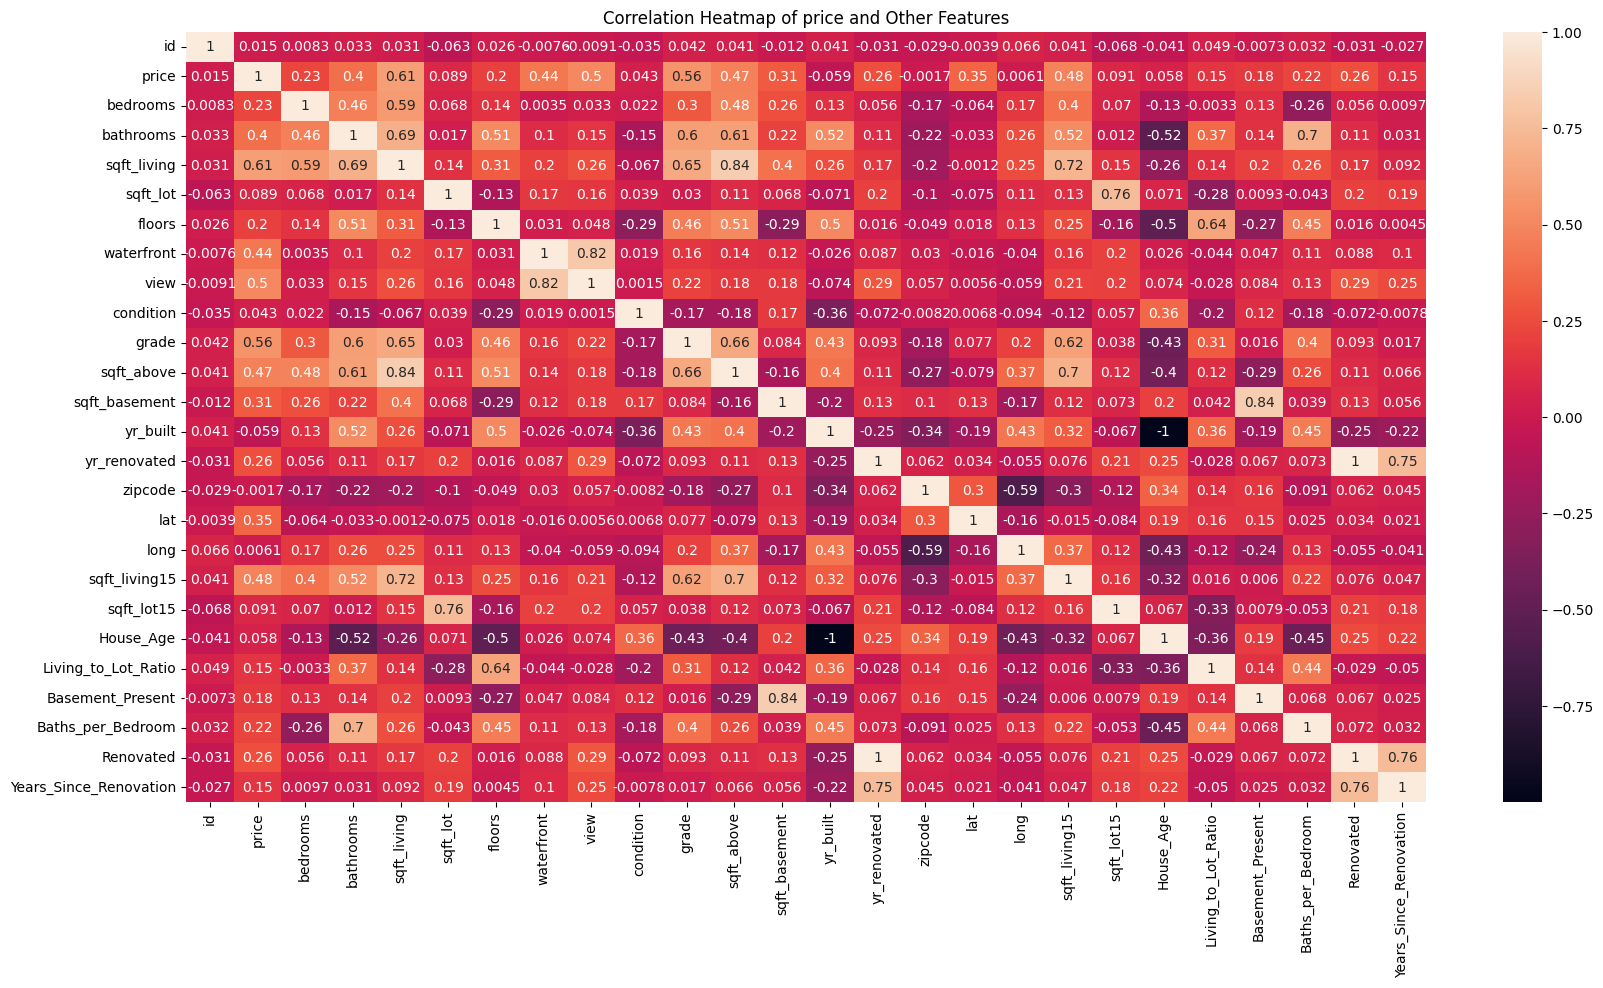

In [ ]:
plt.figure(figsize=(20,10))
sns.heatmap(numeric_corr.corr(), annot=True)
plt.title("Correlation Heatmap of price and Other Features")
plt.show()

**Univariate Analysis**

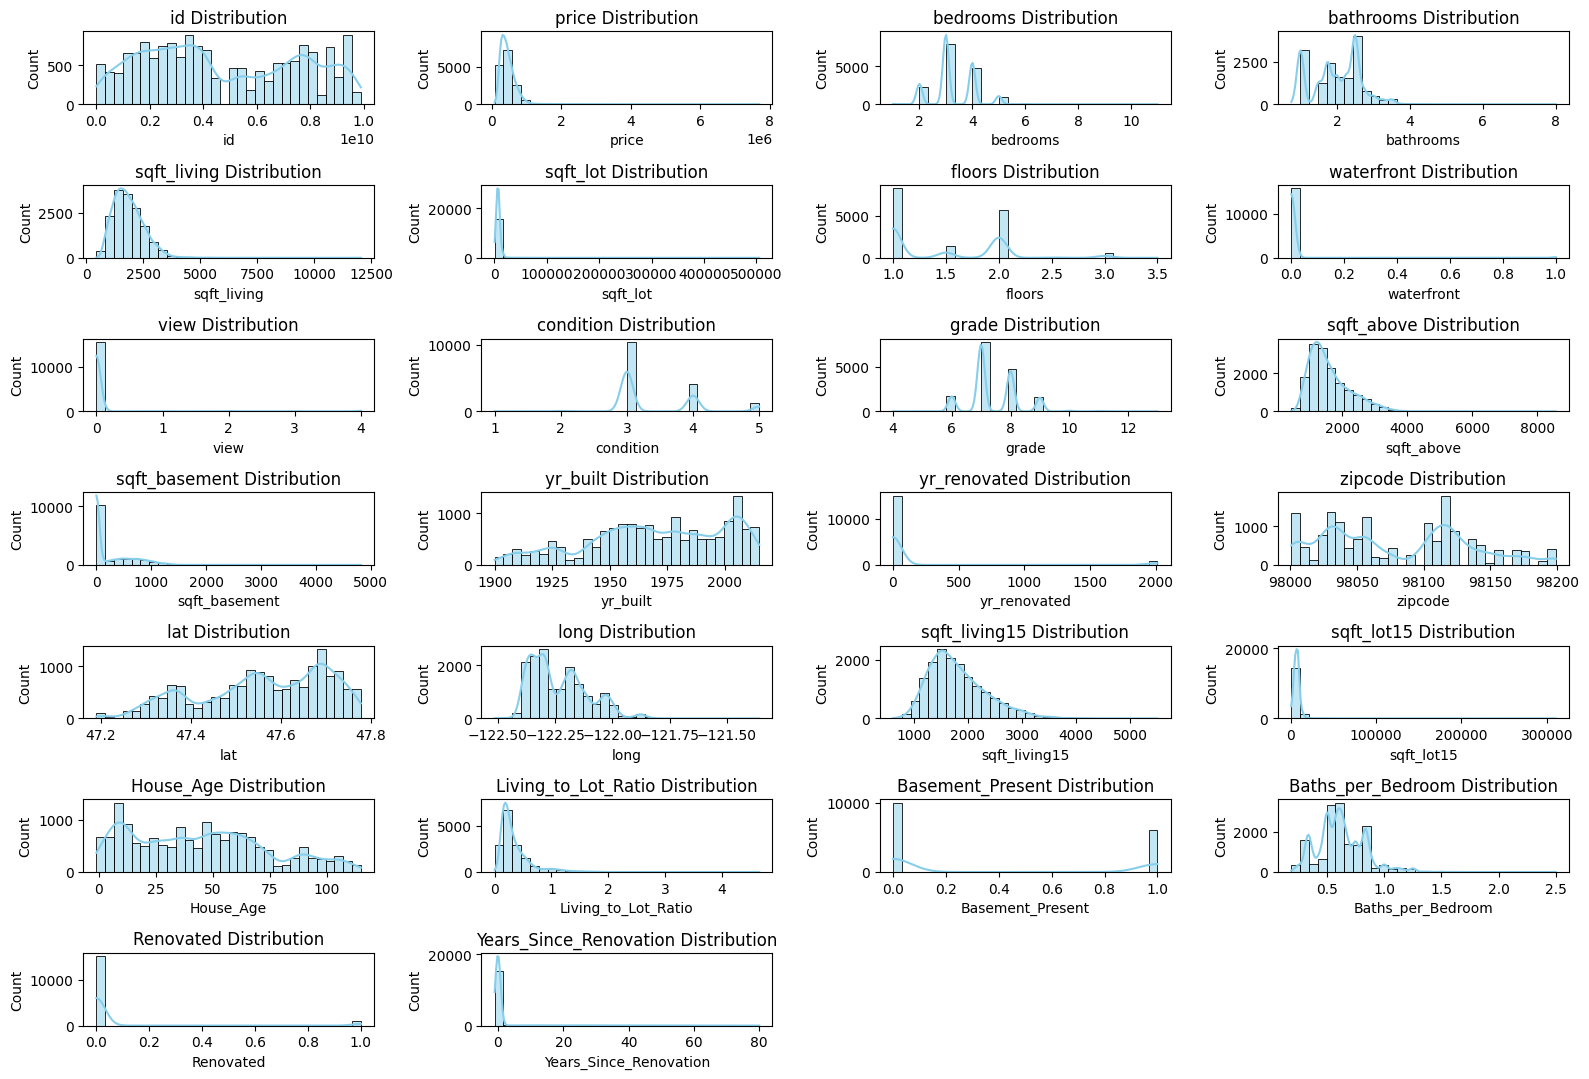

In [ ]:
plt.figure(figsize=(16, 12))
for i, col in enumerate(numeric_corr[:30], 1):
    plt.subplot(8, 4, i)
    sns.histplot(numeric_corr[col], kde=True, bins=30, color='skyblue')
    plt.title(f'{col} Distribution')
plt.tight_layout()
plt.show()

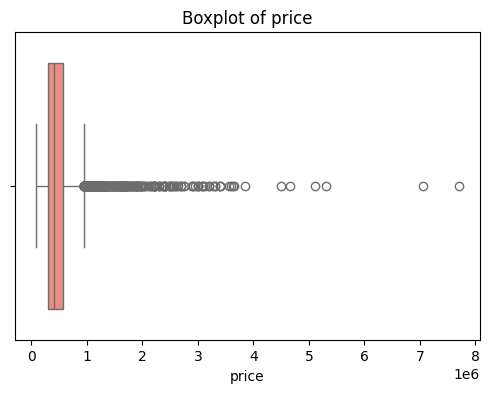

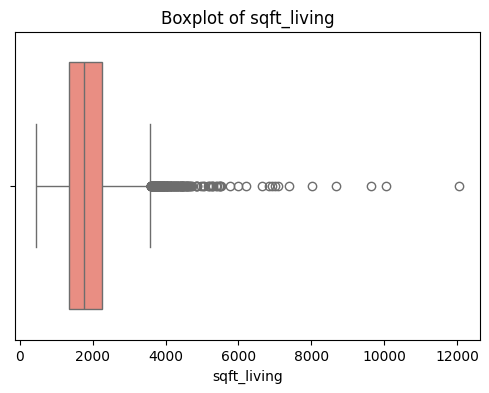

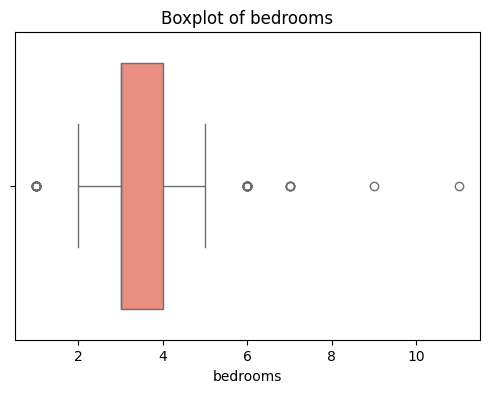

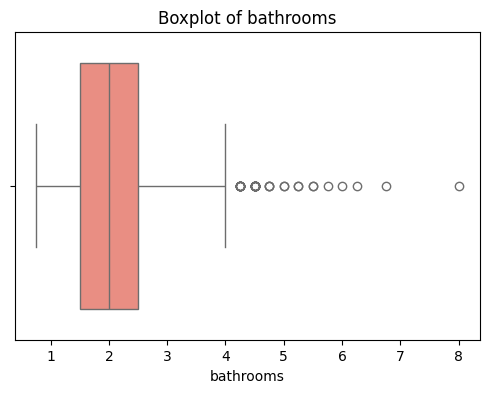

In [ ]:
for col in ['price','sqft_living','bedrooms','bathrooms']:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=numeric_corr[col], color='salmon')
    plt.title(f"Boxplot of {col}")
    plt.show()

**Bivariate Analysis**

Text(0.5, 1.0, 'Price vs Living Area')

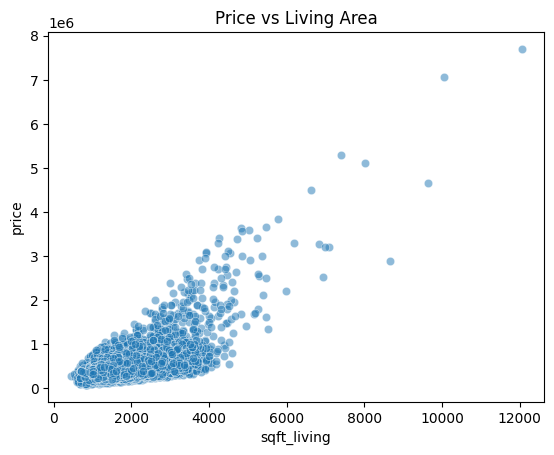

In [ ]:
sns.scatterplot(x='sqft_living', y='price', data=numeric_corr, alpha=0.5)
plt.title('Price vs Living Area')

Text(0.5, 1.0, 'Price vs Grade')

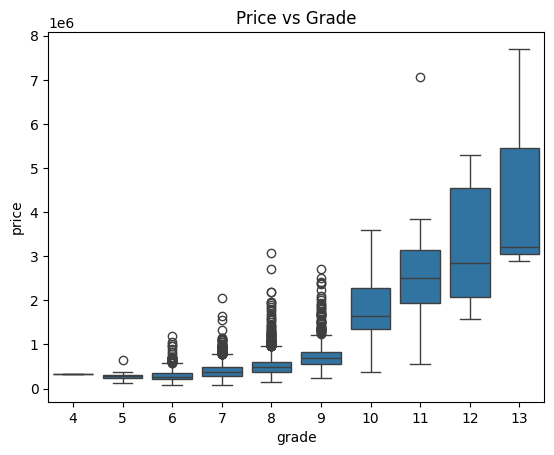

In [ ]:
sns.boxplot(x='grade', y='price', data=numeric_corr)
plt.title('Price vs Grade')

Text(0.5, 1.0, 'Price vs Condition')

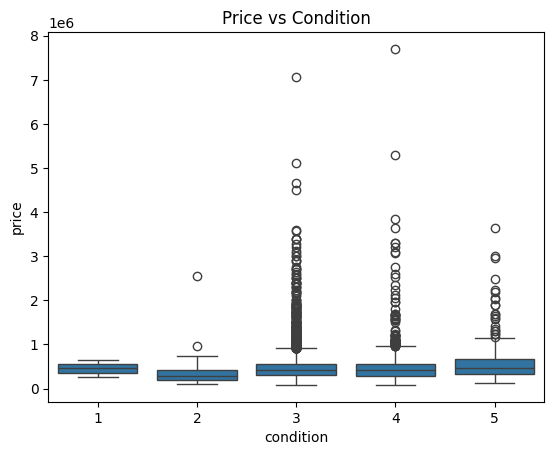

In [ ]:
sns.boxplot(x='condition', y='price', data=numeric_corr)
plt.title('Price vs Condition')

Text(0.5, 1.0, 'Price vs Floors')

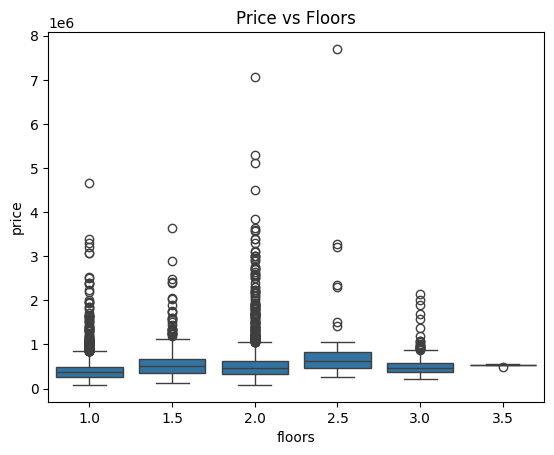

In [ ]:
sns.boxplot(x='floors', y='price', data=numeric_corr)
plt.title('Price vs Floors')

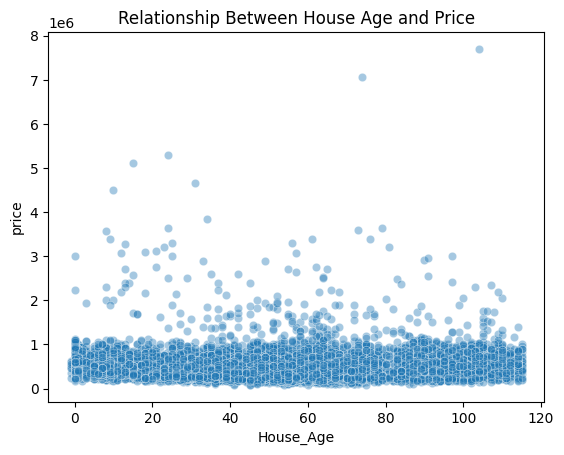

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='House_Age', y='price', data=numeric_corr, alpha=0.4)
plt.title('Relationship Between House Age and Price')
plt.show()

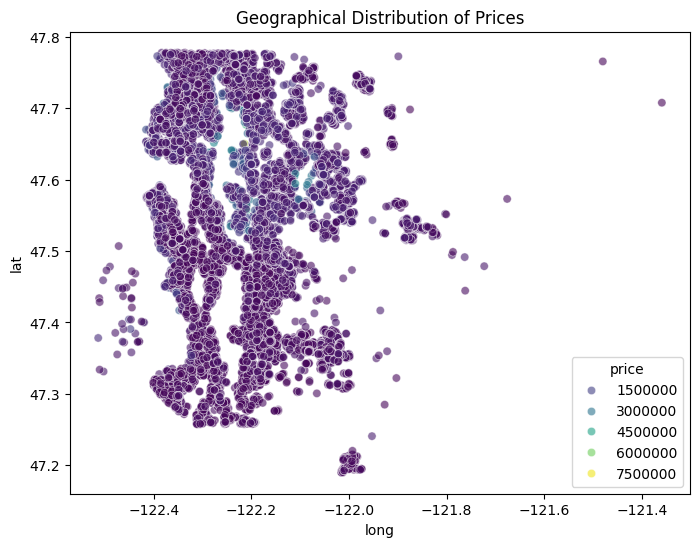

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='long', y='lat', hue='price', data=numeric_corr, palette='viridis', alpha=0.6)
plt.title("Geographical Distribution of Prices")
plt.show()

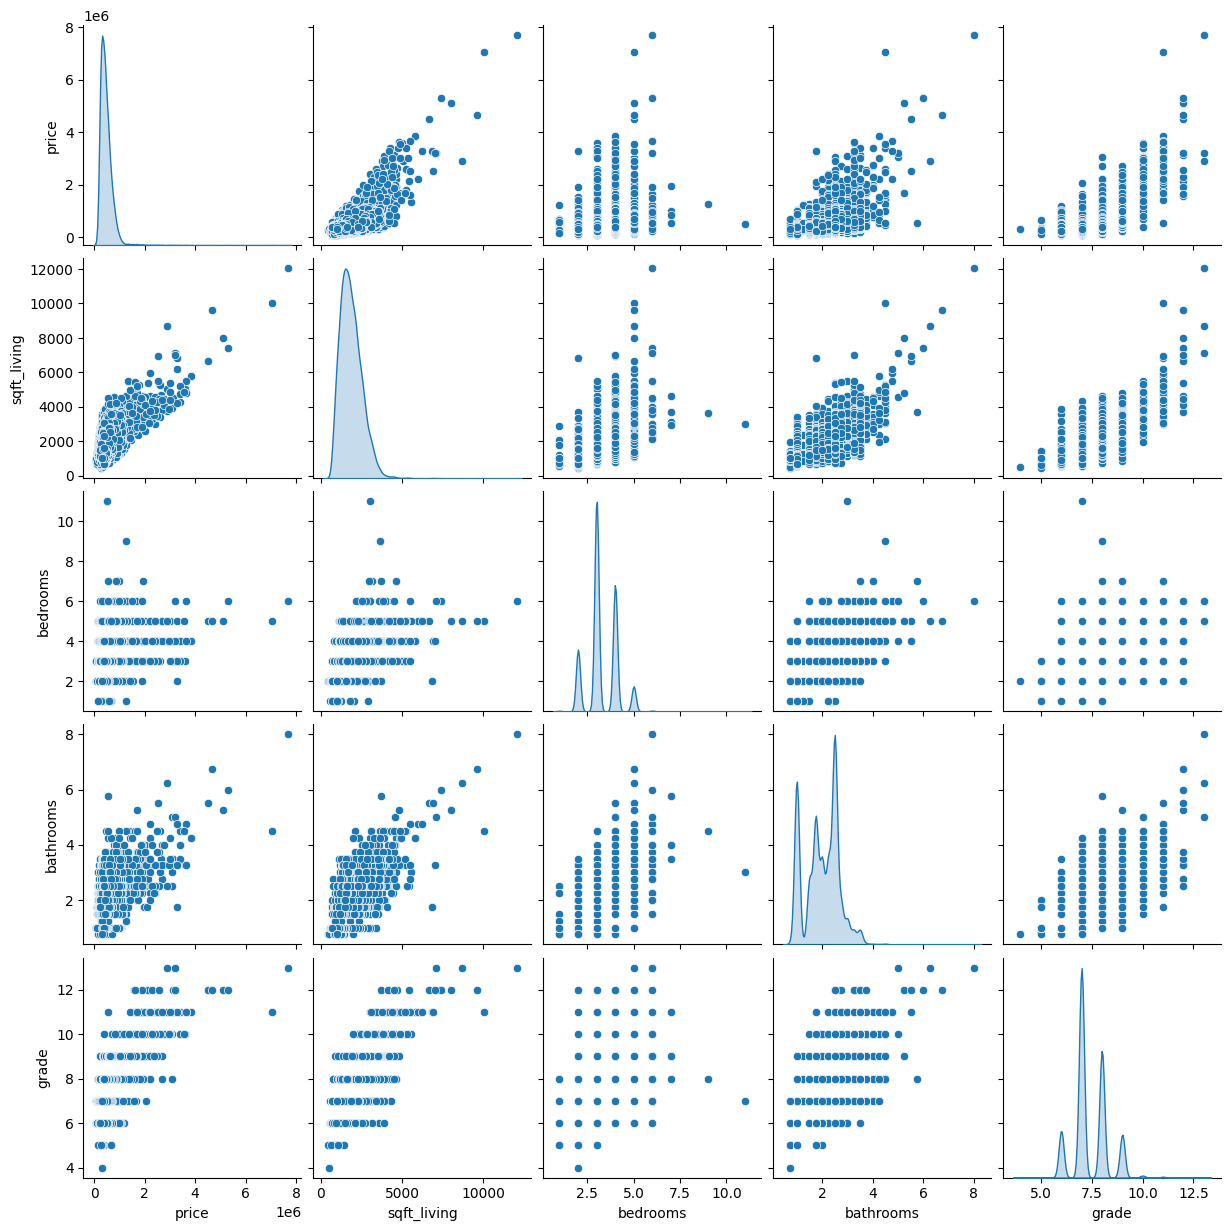

In [ ]:
sns.pairplot(numeric_corr[['price','sqft_living','bedrooms','bathrooms','grade']], diag_kind='kde')
plt.show()

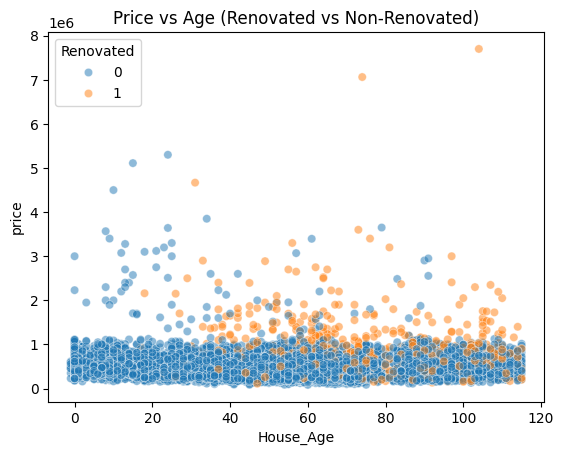

In [ ]:
sns.scatterplot(x='House_Age', y='price', hue='Renovated', data=numeric_corr, alpha=0.5)
plt.title('Price vs Age (Renovated vs Non-Renovated)')
plt.show()

#**Machine Learning Approach**

## **Regression Models**

In [ ]:
features = [
    'House_Age',
    'Living_to_Lot_Ratio',
    'bathrooms',
    'bedrooms',
    'sqft_living',
    'grade',
    'condition',
    'floors',
    'Basement_Present',
    'Baths_per_Bedroom',
    'Renovated',
    'Years_Since_Renovation'
]

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def train_regression_models(df_fe, features):
    # Prepare regression data
    needed_cols_reg = features + ['price']
    df_reg = df_fe.dropna(subset=needed_cols_reg).copy()

    X_reg = df_reg[features]
    y_reg = df_reg['price']

    Xr_train, Xr_test, yr_train, yr_test = train_test_split(
        X_reg, y_reg, test_size=0.2, random_state=42
    )

    reg_pre_linear = ColumnTransformer(
        transformers=[('num', StandardScaler(), features)],
        remainder='drop'
    )
    reg_pre_tree = ColumnTransformer(
        transformers=[('num', 'passthrough', features)],
        remainder='drop'
    )

    reg_models = {
        'LinearRegression': Pipeline([('prep', reg_pre_linear), ('mdl', LinearRegression())]),
        'RandomForest': Pipeline([('prep', reg_pre_tree), ('mdl', RandomForestRegressor(n_estimators=400, random_state=42))]),
        'GradientBoosting': Pipeline([('prep', reg_pre_tree), ('mdl', GradientBoostingRegressor(random_state=42))]),
    }

    reg_results = {}
    reg_fitted = {}

    for name, pipe in reg_models.items():
        pipe.fit(Xr_train, yr_train)
        pred = pipe.predict(Xr_test)
        reg_results[name] = {
            'MAE': mean_absolute_error(yr_test, pred),
            'RMSE': np.sqrt(mean_squared_error(yr_test, pred)),
            'R2': r2_score(yr_test, pred)
        }
        reg_fitted[name] = pipe

    reg_results_df = pd.DataFrame(reg_results).T.sort_values('RMSE')
    best_reg_name = reg_results_df.index[0]
    best_regressor = reg_fitted[best_reg_name]

    print("Regression comparison:")
    print(reg_results_df)
    print(f"\nBest Regressor: {best_reg_name}")

    return best_regressor, reg_results_df, reg_fitted

# Train regression models
best_regressor, reg_results_df, reg_fitted = train_regression_models(df_fe, features)


Regression comparison:
                            MAE           RMSE        R2
RandomForest      102072.691419  145617.530877  0.662846
GradientBoosting  107154.705346  149723.552053  0.643565
LinearRegression  120060.238049  173799.946242  0.519714

Best Regressor: RandomForest


## **Classification Models**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

def train_classification_models(df_fe, features):
    # Create classification target (Top quartile = Luxury)
    lux_thresh = df_fe['price'].quantile(0.75)
    df_fe['Luxury_Class'] = (df_fe['price'] > lux_thresh).astype(int)

    print(f"Luxury threshold: ${lux_thresh:,.0f}")

    needed_cols_cls = features + ['Luxury_Class']
    df_cls = df_fe.dropna(subset=needed_cols_cls).copy()

    X_cls = df_cls[features]
    y_cls = df_cls['Luxury_Class']

    Xc_train, Xc_test, yc_train, yc_test = train_test_split(
        X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
    )

    # Preprocessors
    cls_pre_linear = ColumnTransformer(
        transformers=[('num', StandardScaler(), features)],
        remainder='drop'
    )
    cls_pre_tree = ColumnTransformer(
        transformers=[('num', 'passthrough', features)],
        remainder='drop'
    )

    cls_models = {
        'LogisticRegression': Pipeline([('prep', cls_pre_linear),
                                        ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))]),
        'RandomForest': Pipeline([('prep', cls_pre_tree),
                                  ('clf', RandomForestClassifier(n_estimators=400, class_weight='balanced', random_state=42))]),
        'GradientBoosting': Pipeline([('prep', cls_pre_tree),
                                      ('clf', GradientBoostingClassifier(random_state=42))]),
    }

    cls_results = {}
    cls_fitted = {}

    for name, pipe in cls_models.items():
        pipe.fit(Xc_train, yc_train)
        pred = pipe.predict(Xc_test)

        proba = pipe.predict_proba(Xc_test)[:, 1] if hasattr(pipe, "predict_proba") else None
        cls_results[name] = {
            'Accuracy': accuracy_score(yc_test, pred),
            'Precision': precision_score(yc_test, pred, zero_division=0),
            'Recall': recall_score(yc_test, pred, zero_division=0),
            'F1': f1_score(yc_test, pred, zero_division=0),
            'ROC_AUC': roc_auc_score(yc_test, proba) if proba is not None else np.nan
        }
        cls_fitted[name] = pipe

    # Compare results
    cls_results_df = pd.DataFrame(cls_results).T.sort_values('F1', ascending=False)
    best_cls_name = cls_results_df.index[0]
    best_clf = cls_fitted[best_cls_name]

    print("\nClassification comparison:")
    print(cls_results_df)
    print(f"\nBest Classifier: {best_cls_name}")

    return best_clf, cls_results_df, cls_fitted

# Train classification models
best_clf, cls_results_df, cls_fitted = train_classification_models(df_fe, features)

Luxury threshold: $560,000

Classification comparison:
                    Accuracy  Precision    Recall        F1   ROC_AUC
GradientBoosting    0.845648   0.728788  0.605031  0.661168  0.889169
LogisticRegression  0.797746   0.568286  0.779874  0.657476  0.883933
RandomForest        0.842830   0.729264  0.586164  0.649930  0.890334

Best Classifier: GradientBoosting


In [ ]:
import matplotlib.pyplot as plt

# Plot comparison of model Accuracy and F1
cls_results_df[['Accuracy', 'F1']].plot(kind='bar', figsize=(8,5), color=['#4C72B0','#55A868'])
plt.title("Model Performance Comparison (Accuracy vs F1-Score)")
plt.ylabel("Score")
plt.xlabel("Models")
plt.xticks(rotation=0)
plt.ylim(0.5, 0.9)
plt.tight_layout()
plt.show()

**Helper Functions**

In [ ]:
def _make_input_df(house_age, living_to_lot, bathrooms, bedrooms, sqft_living,
                   grade, condition, floors, basement_present, baths_per_bedroom,
                   renovated, years_since_reno):

    return pd.DataFrame([[
        house_age, living_to_lot, bathrooms, bedrooms, sqft_living,
        grade, condition, floors, basement_present, baths_per_bedroom,
        renovated, years_since_reno
    ]], columns=features)


def predict_price(house_age, living_to_lot, bathrooms, bedrooms, sqft_living,
                  grade, condition, floors, basement_present, baths_per_bedroom,
                  renovated, years_since_reno):


    X_new = _make_input_df(house_age, living_to_lot, bathrooms, bedrooms, sqft_living,
                           grade, condition, floors, basement_present, baths_per_bedroom,
                           renovated, years_since_reno)

    raw_prediction = best_regressor.predict(X_new)[0]

 # Adjustment
    age_adjustment_factor = max(0.7, 1 - (house_age * 0.005))
    adjusted_price = raw_prediction * age_adjustment_factor

    if renovated == 1:
        adjusted_price *= 1.15

    if years_since_reno <= 10 and renovated == 1:
        adjusted_price *= 1.05

    return f"${adjusted_price:,.0f}"


def classify_luxury(house_age, living_to_lot, bathrooms, bedrooms, sqft_living,
                    grade, condition, floors, basement_present, baths_per_bedroom,
                    renovated, years_since_reno):


    X_new = _make_input_df(house_age, living_to_lot, bathrooms, bedrooms, sqft_living,
                           grade, condition, floors, basement_present, baths_per_bedroom,
                           renovated, years_since_reno)

    if hasattr(best_clf, "predict_proba"):
        proba = best_clf.predict_proba(X_new)[0, 1]
    else:
        proba = float(best_clf.predict(X_new)[0])


    if house_age > 80:
        proba *= 0.8
    if renovated == 1:
        proba *= 1.1

    proba = min(max(proba, 0), 1)

    label = "Luxury (Top 25%)" if proba >= 0.5 else "Normal"
    return label, float(proba)

# **Gradio UI**

In [ ]:
import gradio as gr

with gr.Blocks(title="Housing ML — Regression & Classification") as demo:
    gr.Markdown("##Housing ML\nPredict house **price** (regression) and **luxury class** (classification) from structural & quality features.")

    with gr.Tabs():
        with gr.Tab("Price Prediction"):
            with gr.Row():
                house_age = gr.Slider(0, 150, value=20, step=1, label="House Age (years)")
                living_to_lot = gr.Slider(0.0, 2.0, value=0.2, step=0.01, label="Living-to-Lot Ratio")
                bathrooms = gr.Slider(1, 8, value=2, step=1, label="Bathrooms")
                bedrooms = gr.Slider(1, 10, value=3, step=1, label="Bedrooms")
                sqft_living = gr.Slider(400, 10000, value=1800, step=50, label="Sqft Living")
                grade = gr.Slider(1, 13, value=7, step=1, label="Grade (1–13)")
                condition = gr.Slider(1, 5, value=3, step=1, label="Condition (1–5)")
                floors = gr.Slider(1, 3, value=1, step=1, label="Floors")
                basement_present = gr.Radio([0, 1], value=0, label="Basement Present (0/1)")
                baths_per_bedroom = gr.Slider(0.0, 3.0, value=0.67, step=0.01, label="Baths per Bedroom")
                renovated = gr.Radio([0, 1], value=0, label="Renovated (0/1)")
                years_since_reno = gr.Slider(0, 120, value=0, step=1, label="Years Since Renovation")

            price_out = gr.Textbox(label="Predicted Price", interactive=False)
            gr.Button("Predict Price").click(
                predict_price,
                inputs=[house_age, living_to_lot, bathrooms, bedrooms, sqft_living,
                        grade, condition, floors, basement_present, baths_per_bedroom,
                        renovated, years_since_reno],
                outputs=price_out
            )

        with gr.Tab("Luxury Classifier"):
            with gr.Row():
                house_age_c = gr.Slider(0, 150, value=20, step=1, label="House Age (years)")
                living_to_lot_c = gr.Slider(0.0, 2.0, value=0.2, step=0.01, label="Living-to-Lot Ratio")
                bathrooms_c = gr.Slider(1, 8, value=2, step=1, label="Bathrooms")
                bedrooms_c = gr.Slider(1, 10, value=3, step=1, label="Bedrooms")
                sqft_living_c = gr.Slider(400, 10000, value=1800, step=50, label="Sqft Living")
                grade_c = gr.Slider(1, 13, value=7, step=1, label="Grade (1–13)")
                condition_c = gr.Slider(1, 5, value=3, step=1, label="Condition (1–5)")
                floors_c = gr.Slider(1, 3, value=1, step=1, label="Floors")
                basement_present_c = gr.Radio([0, 1], value=0, label="Basement Present (0/1)")
                baths_per_bedroom_c = gr.Slider(0.0, 3.0, value=0.67, step=0.01, label="Baths per Bedroom")
                renovated_c = gr.Radio([0, 1], value=0, label="Renovated (0/1)")
                years_since_reno_c = gr.Slider(0, 120, value=0, step=1, label="Years Since Renovation")

            class_out = gr.Label(num_top_classes=2, label="Predicted Class")
            proba_out = gr.Number(label="Probability of Luxury (class=1)")
            gr.Button("Classify").click(
                classify_luxury,
                inputs=[house_age_c, living_to_lot_c, bathrooms_c, bedrooms_c, sqft_living_c,
                        grade_c, condition_c, floors_c, basement_present_c, baths_per_bedroom_c,
                        renovated_c, years_since_reno_c],
                outputs=[class_out, proba_out]
            )

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://db6a63045badec36bc.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
